# Experiment: Is Early Ricci Predictive of Long-Term Performance?

**Dataset**: Fashion-MNIST (Sneakers vs Sandals)

**Hypothesis**: The average Ricci coefficient measured during the first 10 epochs
of training predicts the long-term accuracy of an architecture after 200 epochs.

## Protocol

- Train all 45 architectures for **200 epochs continuously** - one single run,
  no restarts, no early stopping.
- During **epochs 0–9**: compute layer Ricci every epoch, save activations.
- During **epochs 10–199**: track accuracy only (no Ricci - keeps it fast).
- At the end, compute per architecture:
  - **Early Ricci score** = `mean(avg_ricci, epoch 0..9)`  - a trajectory mean,
    robust to single-epoch noise.
  - **Long-term accuracy** = `mean(test_acc, epoch 0..199)` - rewards fast
    learners that also stay stable.
- Rank both quantities across all 45 architectures and compute
  Pearson, Spearman, and Kendall-tau correlations.

**Key question**: Does a more negative early Ricci score (stronger early geometric
flow) correlate with higher long-term accuracy?


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os, time, json, copy
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse import triu as sp_triu
from scipy.sparse.csgraph import dijkstra
from sklearn.neighbors import kneighbors_graph
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


Device: cpu


In [ ]:

TOTAL_EPOCHS  = 200   # full training budget for every architecture
RICCI_EPOCHS  = 10    # compute Ricci only for epochs 0 .. RICCI_EPOCHS-1

# ── kNN (paper Appendix A.5.1: k = 5% of test-set size)
K_FRAC        = 0.05

# ── Curvature type
CURVATURE_TYPE = 'Augmented-Forman-Ricci'

# ── Optimiser
LR         = 0.001
BATCH_SIZE = 512

# ── Architecture grid (identical across all experiments)
FLAT_DEPTHS       = [4, 5, 6, 7, 8, 9, 10, 11, 12]
FLAT_WIDTHS       = [16, 32, 64, 128]
BOTTLENECK_DEPTHS = [4, 5, 6, 7, 8, 9, 10, 11, 12]
BOTTLENECK_WIDTH  = 128

ARCHITECTURES = []
for d in FLAT_DEPTHS:
    for w in FLAT_WIDTHS:
        ARCHITECTURES.append((f'flat_{d}_{w}', 'flat', d, w))
for d in BOTTLENECK_DEPTHS:
    ARCHITECTURES.append((f'bottleneck_{d}_{BOTTLENECK_WIDTH}', 'bottleneck', d, BOTTLENECK_WIDTH))

print(f'Total architectures : {len(ARCHITECTURES)}')
print(f'Flat : {len(FLAT_DEPTHS)*len(FLAT_WIDTHS)}   Bottleneck : {len(BOTTLENECK_DEPTHS)}')

# ── Output paths
DRIVE_BASE  = '/content/drive/MyDrive/Ricci_Flow_Experiment'
OUTPUT_DIR  = os.path.join(DRIVE_BASE, 'ricci_predictive_experiment')
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'models')
CKPT_PATH   = os.path.join(OUTPUT_DIR, 'checkpoint.json')

for d in [OUTPUT_DIR, MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Output root : {OUTPUT_DIR}')


Total architectures : 45
Flat : 36   Bottleneck : 9
Output root : /content/drive/MyDrive/Ricci_Flow_Experiment/ricci_predictive_experiment


In [ ]:
# ── Load Fashion-MNIST (Sneakers=7 vs Sandals=5)
transform  = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

def filter_classes(dataset, class_a=5, class_b=7):
    mask = (dataset.targets == class_a) | (dataset.targets == class_b)
    X    = dataset.data[mask].float() / 255.0
    y    = dataset.targets[mask].float()
    y    = (y == class_b).float()   # Sneakers=1, Sandals=0
    return X.to(device), y.to(device)

X_train, y_train = filter_classes(train_data)
X_test,  y_test  = filter_classes(test_data)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True)

print(f'Train : {X_train.shape}   Test : {X_test.shape}')
print(f'Class balance — Train : {y_train.mean():.3f}   Test : {y_test.mean():.3f}')

# k = 5 % of test-set size (paper Appendix A.5.1)
K = max(1, int(round(K_FRAC * X_test.shape[0])))
print(f'kNN k = {K}  ({K_FRAC*100:.0f}% of {X_test.shape[0]} samples)')


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.62MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.0MB/s]


Train : torch.Size([12000, 28, 28])   Test : torch.Size([2000, 28, 28])
Class balance — Train : 0.500   Test : 0.500
kNN k = 100  (5% of 2000 samples)


In [ ]:
def get_bottleneck_widths(depth, max_width):
    mid = depth // 2
    widths = []
    for i in range(depth):
        if depth % 2 == 0:
            dist_from_edge = min(i, depth - 1 - i)
        else:
            dist_from_edge = min(i, depth - 1 - i)
        reduction = 2 ** (mid - dist_from_edge) if dist_from_edge < mid else 1
        widths.append(max(max_width // reduction, 8))
    return widths


class DNN(nn.Module):
    def __init__(self, input_dim=784, layer_widths=None, hidden_units=None, depth=None):
        super().__init__()
        if layer_widths is None:
            layer_widths = [hidden_units] * depth
        self.flatten    = nn.Flatten()
        dims            = [input_dim] + layer_widths + [1]
        layers          = []
        for i in range(len(dims) - 1):
            lin = nn.Linear(dims[i], dims[i + 1])
            nn.init.kaiming_normal_(lin.weight, nonlinearity='relu')
            nn.init.zeros_(lin.bias)
            layers.append(lin)
        self.layers     = nn.ModuleList(layers)
        self.batchnorms = nn.ModuleList(
            [nn.BatchNorm1d(dims[i + 1]) for i in range(len(dims) - 2)])

    def forward(self, x):
        x = self.flatten(x)
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batchnorms[i](x)
            x = torch.relu(x)
        return self.layers[-1](x)

    def features(self, x):
        """Hidden-layer activations only (output excluded — paper Section 3.2)."""
        x     = self.flatten(x)
        feats = [x.detach().cpu().numpy()]
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.batchnorms[i](x)
            x = torch.relu(x)
            feats.append(x.detach().cpu().numpy())
        return feats


def build_model(arch_type, depth, width):
    if arch_type == 'bottleneck':
        return DNN(input_dim=784, layer_widths=get_bottleneck_widths(depth, width)).to(device)
    return DNN(input_dim=784, hidden_units=width, depth=depth).to(device)


_m = build_model('flat', 5, 64)
print(f'Flat 5/64 layers : {[(l.in_features, l.out_features) for l in _m.layers]}')
del _m
print('\u2705 DNN defined')


Flat 5/64 layers : [(784, 64), (64, 64), (64, 64), (64, 64), (64, 64), (64, 1)]
✅ DNN defined


In [ ]:
def accuracy_fn(y_true, y_pred):
    return torch.eq(y_true, y_pred).sum().item() / len(y_pred)

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total = 0.0
    for Xb, yb in loader:
        logits = model(Xb).squeeze()
        loss   = loss_fn(logits, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * len(Xb)
    return total / len(loader.dataset)

def evaluate(model, X, y):
    model.eval()
    with torch.inference_mode():
        logits = model(X).squeeze()
        preds  = torch.round(torch.sigmoid(logits))
        acc    = accuracy_fn(y, preds)
        loss   = nn.BCEWithLogitsLoss()(logits, y).item()
    return acc, loss

print('\u2705 Training utilities defined')


✅ Training utilities defined


In [ ]:
def compute_augmented_forman_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2      = A @ A
    Ric     = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i, j] = 4 - degrees[i] - degrees[j] + 3 * A2[i, j]
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_forman_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    Ric     = lil_matrix(A.shape, dtype=np.int32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        Ric[i, j] = 4 - degrees[i] - degrees[j]
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_approx_ollivier_ricci(A):
    A       = csr_matrix(A)
    degrees = A @ np.ones(A.shape[0])
    A2      = A @ A
    Ric     = lil_matrix(A.shape, dtype=np.float32)
    rows, cols = sp_triu(A, k=1).nonzero()
    for i, j in zip(rows, cols):
        t  = A2[i, j]; di, dj = degrees[i], degrees[j]
        Ric[i, j] = (0.5*(t/max(di,dj))
                     - 0.5*(max(0, 1-1/di-1/dj-t/min(di,dj))
                            + max(0, 1-1/di-1/dj-t/max(di,dj))
                            - t/max(di,dj)))
        Ric[j, i] = Ric[i, j]
    return Ric.tocsr()

def compute_curvature(A, curv):
    if   curv == 'Forman-Ricci':           return compute_forman_ricci(A)
    elif curv == 'Augmented-Forman-Ricci': return compute_augmented_forman_ricci(A)
    elif curv == 'Approx-Ollivier-Ricci':  return compute_approx_ollivier_ricci(A)
    else: raise ValueError(f'Unknown curvature: {curv}')

def compute_ricci_from_features(features, k, curv='Augmented-Forman-Ricci'):
    """Layer Ricci coefficients (paper Section 3.2).
    features : [input_acts, hidden_1, ..., hidden_L]  — output excluded.
    Returns  : np.ndarray of shape (len(features)-1,)
    """
    depth      = len(features)
    kNN_graphs = []
    for feat in features:
        g = kneighbors_graph(feat, k, mode='connectivity', include_self=False)
        kNN_graphs.append(g.maximum(g.T))
    apsps      = [dijkstra(csgraph=g, directed=False, unweighted=True,
                           return_predecessors=False) for g in kNN_graphs]
    curvatures = [compute_curvature(kNN_graphs[i], curv) for i in range(depth - 1)]
    layer_ricci = np.empty(depth - 1)
    for i in range(depth - 1):
        sc, eta = [], []
        for x in range(len(features[0])):
            S1 = kNN_graphs[i][x].indices
            ec, connected = 0, True
            for y in S1:
                if apsps[i+1][x, y] == np.inf:
                    connected = False
                else:
                    ec += apsps[i+1][x, y] - apsps[i][x, y]
            if connected:
                sc.append(np.divide(curvatures[i][x].sum(),
                                    kNN_graphs[i][x].count_nonzero()))
                eta.append(ec / len(S1))
        layer_ricci[i] = pearsonr(sc, eta)[0] if len(sc) >= 2 else np.nan
    return layer_ricci

print('\u2705 Curvature functions defined')


✅ Curvature functions defined


In [ ]:
def load_json(path, default):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

def save_json(path, obj):
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)

def save_activations(epoch_dir, hidden_acts):
    """One .npy file per hidden layer."""
    os.makedirs(epoch_dir, exist_ok=True)
    for i, act in enumerate(hidden_acts):
        np.save(os.path.join(epoch_dir, f'hidden_{i}.npy'), act)

print('\u2705 IO / checkpoint utilities defined')


✅ IO / checkpoint utilities defined


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════════
#
# Each architecture runs for TOTAL_EPOCHS = 200 epochs continuously.
#
# Epochs 0 .. RICCI_EPOCHS-1  (0-9):
#   • train one epoch
#   • evaluate accuracy
#   • compute layer Ricci on test-set hidden activations
#   • save: activations (one .npy per hidden layer), layer_ricci.npy, metrics.npy
#
# Epochs RICCI_EPOCHS .. TOTAL_EPOCHS-1  (10-199):
#   • train one epoch
#   • evaluate accuracy only  ← no Ricci, keeps runtime manageable
#   • save: metrics.npy only
#
# After all 200 epochs:
#   • save final model weights
#   • append summary entry (early_ricci_score, long_term_acc, full acc history)
#   • update checkpoint
#
# Checkpoint is per-architecture.
# ───────────────────────────────────────────────────────────────────────────────

ckpt      = load_json(CKPT_PATH, {'completed': []})
completed = set(ckpt['completed'])

summary_path = os.path.join(OUTPUT_DIR, 'summary.json')
summary      = load_json(summary_path, [])
done_names   = {r['name'] for r in summary}

t_start = time.time()

for arch_idx, (name, arch_type, depth, width) in enumerate(ARCHITECTURES):

    if name in completed:
        print(f'[{arch_idx+1:2d}/{len(ARCHITECTURES)}] {name} — skipped (checkpoint)')
        continue

    print(f'\n[{arch_idx+1:2d}/{len(ARCHITECTURES)}] {name}'
          f'  type={arch_type}  depth={depth}  width={width}')

    arch_dir = os.path.join(MODELS_DIR, name)
    os.makedirs(arch_dir, exist_ok=True)

    model     = build_model(arch_type, depth, width)
    loss_fn   = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    # ── per-epoch records
    epoch_history = []   # list of dicts, one per epoch
    early_ricci_values = []   # avg_ricci for epochs 0..RICCI_EPOCHS-1

    for epoch in range(TOTAL_EPOCHS):

        # 1. train
        train_loss          = train_one_epoch(model, train_loader, optimizer, loss_fn)
        test_acc, test_loss = evaluate(model, X_test,  y_test)
        train_acc, _        = evaluate(model, X_train, y_train)

        epoch_entry = {
            'epoch':      epoch,
            'train_acc':  float(train_acc),
            'test_acc':   float(test_acc),
            'train_loss': float(train_loss),
            'test_loss':  float(test_loss),
        }

        # 2. Ricci — only during the early probe window
        if epoch < RICCI_EPOCHS:
            model.eval()
            with torch.inference_mode():
                feats = model.features(X_test)   # [input, h1..hL], output excluded

            hidden_acts = feats[1:]
            if len(hidden_acts) < 2:
                raise ValueError(
                    f'{name}: need >=2 hidden layers, got {len(hidden_acts)}')

            layer_ricci = compute_ricci_from_features(
                hidden_acts, K, curv=CURVATURE_TYPE)
            avg_ricci   = float(np.nanmean(layer_ricci))
            early_ricci_values.append(avg_ricci)

            epoch_entry['avg_ricci']   = avg_ricci
            epoch_entry['layer_ricci'] = layer_ricci.tolist()

            # save activations + ricci for this epoch
            ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            save_activations(ep_dir, hidden_acts)
            np.save(os.path.join(ep_dir, 'layer_ricci.npy'), layer_ricci)
            np.save(os.path.join(ep_dir, 'metrics.npy'),
                    np.array([train_acc, test_acc, train_loss, test_loss]))

            print(f'  ep {epoch:3d}  train={train_acc:.4f}  test={test_acc:.4f}'
                  f'  avg_ricci={avg_ricci:+.4f}')

        else:
            # accuracy-only epoch — just save a small metrics file
            ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            os.makedirs(ep_dir, exist_ok=True)
            np.save(os.path.join(ep_dir, 'metrics.npy'),
                    np.array([train_acc, test_acc, train_loss, test_loss]))

            if (epoch + 1) % 50 == 0 or epoch == TOTAL_EPOCHS - 1:
                print(f'  ep {epoch:3d}  train={train_acc:.4f}  test={test_acc:.4f}')

        epoch_history.append(epoch_entry)

    # ── save model weights
    torch.save(model.state_dict(),
               os.path.join(arch_dir, 'model_weights_final.pth'))

    # ── save full epoch history
    save_json(os.path.join(arch_dir, 'epoch_history.json'), epoch_history)

    # ── compute summary scores ───────────────────────────────────────────────
    # Early Ricci score: mean of avg_ricci across epochs 0..RICCI_EPOCHS-1
    # More negative = stronger early geometric flow
    early_ricci_score = float(np.nanmean(early_ricci_values))

    # Long-term accuracy: mean test_acc across ALL 200 epochs
    # Rewards architectures that learn fast AND stay stable
    all_test_accs     = [e['test_acc'] for e in epoch_history]
    long_term_acc     = float(np.mean(all_test_accs))

    # Also record final epoch accuracy and best accuracy for reference
    final_acc         = float(epoch_history[-1]['test_acc'])
    best_acc          = float(max(all_test_accs))
    best_acc_epoch    = int(np.argmax(all_test_accs))

    entry = {
        'name':               name,
        'type':               arch_type,
        'depth':              depth,
        'width':              width,
        # early geometric signal
        'early_ricci_score':  early_ricci_score,
        'early_ricci_per_epoch': early_ricci_values,  # full trajectory (10 values)
        # long-term performance
        'long_term_acc':      long_term_acc,
        'final_acc':          final_acc,
        'best_acc':           best_acc,
        'best_acc_epoch':     best_acc_epoch,
    }
    summary.append(entry)
    save_json(summary_path, summary)

    # checkpoint
    completed.add(name)
    save_json(CKPT_PATH, {'completed': list(completed)})

    print(f'  → early_ricci_score={early_ricci_score:+.4f}  '
          f'long_term_acc={long_term_acc:.4f}  '
          f'final_acc={final_acc:.4f}')

    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\n\u2705 Training complete in {(time.time()-t_start)/3600:.2f}h')
print(f'   {len(summary)} architectures saved to {summary_path}')


[ 1/45] flat_4_16 — skipped (checkpoint)
[ 2/45] flat_4_32 — skipped (checkpoint)
[ 3/45] flat_4_64 — skipped (checkpoint)
[ 4/45] flat_4_128 — skipped (checkpoint)
[ 5/45] flat_5_16 — skipped (checkpoint)
[ 6/45] flat_5_32 — skipped (checkpoint)
[ 7/45] flat_5_64 — skipped (checkpoint)
[ 8/45] flat_5_128 — skipped (checkpoint)
[ 9/45] flat_6_16 — skipped (checkpoint)
[10/45] flat_6_32 — skipped (checkpoint)
[11/45] flat_6_64 — skipped (checkpoint)
[12/45] flat_6_128 — skipped (checkpoint)
[13/45] flat_7_16 — skipped (checkpoint)
[14/45] flat_7_32 — skipped (checkpoint)
[15/45] flat_7_64 — skipped (checkpoint)
[16/45] flat_7_128 — skipped (checkpoint)
[17/45] flat_8_16 — skipped (checkpoint)
[18/45] flat_8_32 — skipped (checkpoint)
[19/45] flat_8_64 — skipped (checkpoint)
[20/45] flat_8_128 — skipped (checkpoint)
[21/45] flat_9_16 — skipped (checkpoint)
[22/45] flat_9_32 — skipped (checkpoint)
[23/45] flat_9_64 — skipped (checkpoint)
[24/45] flat_9_128 — skipped (checkpoint)
[25/45] fl

In [ ]:
# ── Load summary
summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if not summary:
    print('Run the training cell first.')
else:
    names        = [r['name']              for r in summary]
    ricci_scores = [r['early_ricci_score'] for r in summary]
    lt_accs      = [r['long_term_acc']     for r in summary]
    final_accs   = [r['final_acc']         for r in summary]

    ricci_arr = np.array(ricci_scores)
    lt_arr    = np.array(lt_accs)

    # ── Pearson (linear correlation)
    pear_r, pear_p   = pearsonr(ricci_arr, lt_arr)

    # ── Spearman (rank correlation)
    spear_r, spear_p = spearmanr(ricci_arr, lt_arr)

    # ── Kendall-tau (concordance)
    kend_tau, kend_p = kendalltau(ricci_arr, lt_arr)

    print('═' * 60)
    print('CORRELATION: Early Ricci Score  vs  Long-Term Accuracy')
    print('═' * 60)
    print(f'  Pearson  r   = {pear_r:+.4f}   p = {pear_p:.4f}')
    print(f'  Spearman rho = {spear_r:+.4f}   p = {spear_p:.4f}')
    print(f'  Kendall  tau = {kend_tau:+.4f}   p = {kend_p:.4f}')
    print('═' * 60)
    print()
    print('Interpretation:')
    print('  r / rho / tau < 0  →  more negative early Ricci predicts higher accuracy')
    print('  r / rho / tau > 0  →  no predictive relationship in expected direction')
    print()

    # save correlation results
    corr_results = {
        'pearson_r':   pear_r,  'pearson_p':   pear_p,
        'spearman_r':  spear_r, 'spearman_p':  spear_p,
        'kendall_tau': kend_tau,'kendall_p':   kend_p,
        'n':           len(summary),
    }
    save_json(os.path.join(OUTPUT_DIR, 'correlation_results.json'), corr_results)
    print(f'Saved to {os.path.join(OUTPUT_DIR, "correlation_results.json")}')


════════════════════════════════════════════════════════════
CORRELATION: Early Ricci Score  vs  Long-Term Accuracy
════════════════════════════════════════════════════════════
  Pearson  r   = -0.5051   p = 0.0004
  Spearman rho = -0.5715   p = 0.0000
  Kendall  tau = -0.3919   p = 0.0001
════════════════════════════════════════════════════════════

Interpretation:
  r / rho / tau < 0  →  more negative early Ricci predicts higher accuracy
  r / rho / tau > 0  →  no predictive relationship in expected direction

Saved to /content/drive/MyDrive/Ricci_Flow_Experiment/ricci_predictive_experiment/correlation_results.json


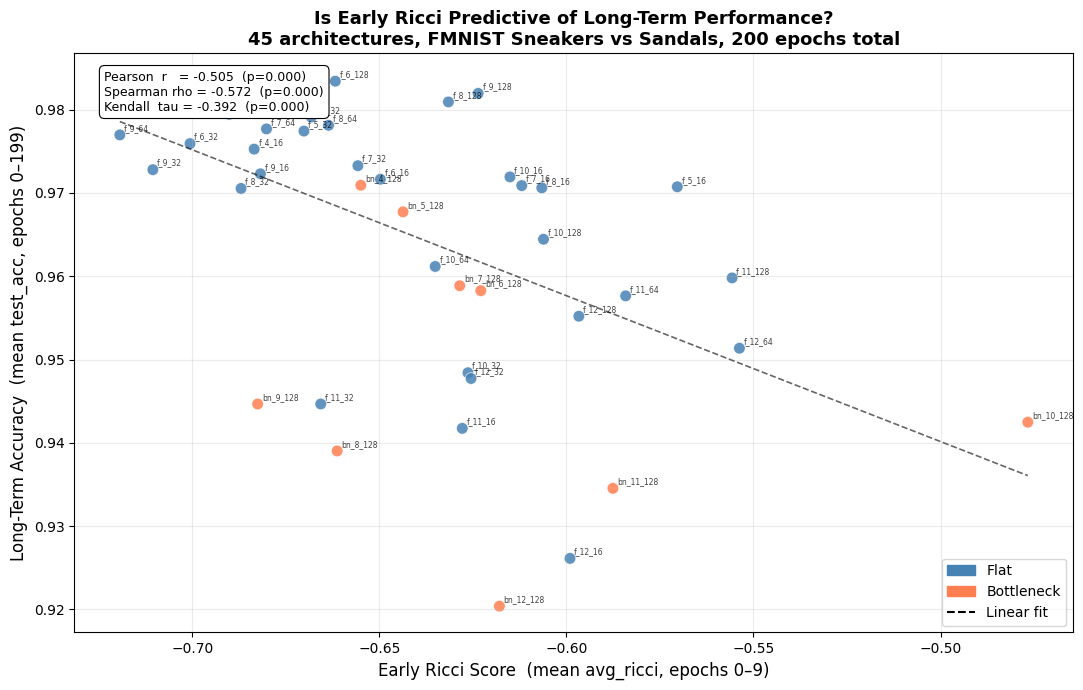

✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/ricci_predictive_experiment/ricci_vs_longterm_acc_scatter.png


In [ ]:
# ── Scatter plot: Early Ricci Score vs Long-Term Accuracy
summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
corr    = load_json(os.path.join(OUTPUT_DIR, 'correlation_results.json'), {})

if not summary:
    print('Run training and correlation cells first.')
else:
    ricci_scores = np.array([r['early_ricci_score'] for r in summary])
    lt_accs      = np.array([r['long_term_acc']      for r in summary])
    arch_types   = [r['type'] for r in summary]
    names        = [r['name'] for r in summary]

    colors = ['steelblue' if t == 'flat' else 'coral' for t in arch_types]

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(ricci_scores, lt_accs, c=colors, s=70,
               alpha=0.85, edgecolors='white', linewidths=0.5)

    # regression line
    m, b    = np.polyfit(ricci_scores, lt_accs, 1)
    x_range = np.linspace(ricci_scores.min(), ricci_scores.max(), 200)
    ax.plot(x_range, m * x_range + b, 'k--', lw=1.2, alpha=0.6, label='Linear fit')

    # label every point
    for i, (r, a, name) in enumerate(zip(ricci_scores, lt_accs, names)):
        short = name.replace('bottleneck_', 'bn_').replace('flat_', 'f_')
        ax.annotate(short, (r, a), fontsize=5.5, alpha=0.75,
                    xytext=(3, 3), textcoords='offset points')

    # correlation box
    if corr:
        box_txt = (f"Pearson  r   = {corr['pearson_r']:+.3f}  (p={corr['pearson_p']:.3f})\n"
                   f"Spearman rho = {corr['spearman_r']:+.3f}  (p={corr['spearman_p']:.3f})\n"
                   f"Kendall  tau = {corr['kendall_tau']:+.3f}  (p={corr['kendall_p']:.3f})")
        ax.text(0.03, 0.97, box_txt, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='black', linewidth=0.8))

    # legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Flat'),
                        Patch(color='coral',     label='Bottleneck'),
                        plt.Line2D([0],[0], color='k', ls='--', label='Linear fit')],
              fontsize=10, loc='lower right')

    ax.set_xlabel(f'Early Ricci Score  (mean avg_ricci, epochs 0–{RICCI_EPOCHS-1})',
                  fontsize=12)
    ax.set_ylabel(f'Long-Term Accuracy  (mean test_acc, epochs 0–{TOTAL_EPOCHS-1})',
                  fontsize=12)
    ax.set_title('Is Early Ricci Predictive of Long-Term Performance?\n'
                 f'45 architectures, FMNIST Sneakers vs Sandals, '
                 f'{TOTAL_EPOCHS} epochs total',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'ricci_vs_longterm_acc_scatter.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved → {save_path}')


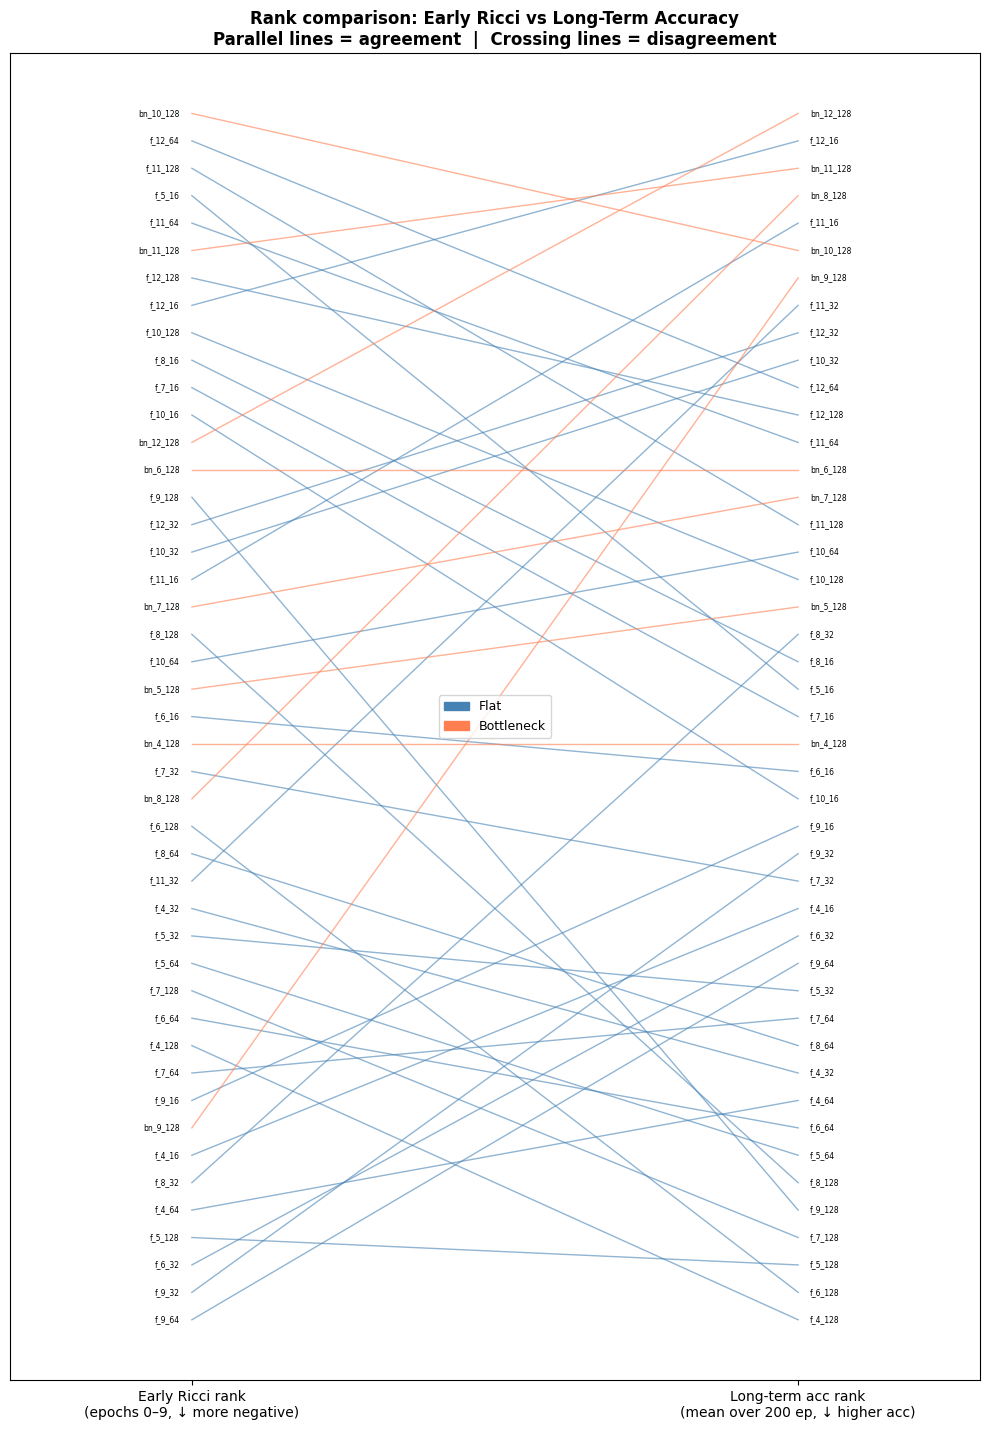

✅ Saved → /content/drive/MyDrive/Ricci_Flow_Experiment/ricci_predictive_experiment/rank_comparison.png


In [ ]:
# ── Rank plot: side-by-side ranking comparison ───────────────────────────────
# Architectures ordered by early Ricci (left) vs long-term accuracy (right).
# Lines connect the same architecture — crossing lines = rank disagreement.
summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if not summary:
    print('Run training cell first.')
else:
    ricci_scores = np.array([r['early_ricci_score'] for r in summary])
    lt_accs      = np.array([r['long_term_acc']      for r in summary])
    names        = [r['name'] for r in summary]
    arch_types   = [r['type'] for r in summary]

    # rank: lower early_ricci (more negative) = rank 1 = best geometrically
    ricci_ranks = np.argsort(ricci_scores)          # ascending: most negative first
    # rank: higher lt_acc = rank 1 = best performer
    acc_ranks   = np.argsort(lt_accs)[::-1]         # descending: highest acc first

    ricci_rank_of = {names[i]: int(pos) for pos, i in enumerate(ricci_ranks)}
    acc_rank_of   = {names[i]: int(pos) for pos, i in enumerate(acc_ranks)}

    n    = len(names)
    fig, ax = plt.subplots(figsize=(10, max(8, n * 0.32)))

    colors = ['steelblue' if t == 'flat' else 'coral' for t in arch_types]

    for i, name in enumerate(names):
        rr = ricci_rank_of[name]
        ar = acc_rank_of[name]
        ax.plot([0, 1], [rr, ar], color=colors[i], alpha=0.6, lw=1.0)
        ax.text(-0.02, rr, name.replace('bottleneck_','bn_').replace('flat_','f_'),
                ha='right', va='center', fontsize=5.5)
        ax.text(1.02, ar, name.replace('bottleneck_','bn_').replace('flat_','f_'),
                ha='left',  va='center', fontsize=5.5)

    ax.set_xlim(-0.3, 1.3)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'Early Ricci rank\n(epochs 0–{RICCI_EPOCHS-1}, ↓ more negative)',
                         f'Long-term acc rank\n(mean over {TOTAL_EPOCHS} ep, ↓ higher acc)'],
                        fontsize=10)
    ax.set_yticks([])
    ax.set_title('Rank comparison: Early Ricci vs Long-Term Accuracy\n'
                 'Parallel lines = agreement  |  Crossing lines = disagreement',
                 fontsize=12, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Flat'),
                        Patch(color='coral',     label='Bottleneck')],
              fontsize=9, loc='center')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'rank_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Saved → {save_path}')


In [ ]:
# ── Export full results CSV
import csv

summary = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
corr    = load_json(os.path.join(OUTPUT_DIR, 'correlation_results.json'), {})

if not summary:
    print('Run training cell first.')
else:
    ricci_scores = [r['early_ricci_score'] for r in summary]
    lt_accs      = [r['long_term_acc']      for r in summary]

    # compute ranks
    ricci_rank = {r['name']: int(rk) + 1
                  for rk, r in zip(np.argsort(ricci_scores), summary)}
    acc_rank   = {r['name']: int(rk) + 1
                  for rk, r in zip(np.argsort(lt_accs)[::-1], summary)}

    rows = []
    for r in summary:
        row = {
            'name':               r['name'],
            'type':               r['type'],
            'depth':              r['depth'],
            'width':              r['width'],
            'early_ricci_score':  round(r['early_ricci_score'], 6),
            'ricci_rank':         ricci_rank[r['name']],
            'long_term_acc':      round(r['long_term_acc'], 6),
            'acc_rank':           acc_rank[r['name']],
            'final_acc':          round(r['final_acc'], 6),
            'best_acc':           round(r['best_acc'], 6),
            'best_acc_epoch':     r['best_acc_epoch'],
        }
        # append per-epoch ricci scores as separate columns
        for ep, val in enumerate(r['early_ricci_per_epoch']):
            row[f'ricci_ep{ep}'] = round(val, 6)
        rows.append(row)

    # sort by acc_rank for readability
    rows.sort(key=lambda x: x['acc_rank'])

    csv_path = os.path.join(OUTPUT_DIR, 'ricci_predictive_results.csv')
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)

    print(f'\u2705 Saved {len(rows)} rows → {csv_path}')

    # print top-10 and bottom-10 by acc rank
    print(f'\n{"Rank":>4}  {"Architecture":<26}  {"Early Ricci":>12}  '
          f'{"Ricci Rank":>10}  {"LT Acc":>8}')
    print('─' * 68)
    to_show = rows[:10] + [None] + rows[-10:]
    for row in to_show:
        if row is None:
            print('  ...')
            continue
        print(f'{row["acc_rank"]:>4}  {row["name"]:<26}  '
              f'{row["early_ricci_score"]:>+12.4f}  '
              f'{row["ricci_rank"]:>10}  '
              f'{row["long_term_acc"]:>8.4f}')

    if corr:
        print(f'\nCorrelations (early Ricci vs long-term acc, n={corr["n"]}):')
        print(f'  Pearson  r   = {corr["pearson_r"]:+.4f}  p={corr["pearson_p"]:.4f}')
        print(f'  Spearman rho = {corr["spearman_r"]:+.4f}  p={corr["spearman_p"]:.4f}')
        print(f'  Kendall  tau = {corr["kendall_tau"]:+.4f}  p={corr["kendall_p"]:.4f}')


✅ Saved 45 rows → /content/drive/MyDrive/Ricci_Flow_Experiment/ricci_predictive_experiment/ricci_predictive_results.csv

Rank  Architecture                 Early Ricci  Ricci Rank    LT Acc
────────────────────────────────────────────────────────────────────
   1  flat_7_128                       -0.6749           2    0.9820
   2  flat_6_32                        -0.7006          15    0.9759
   3  flat_6_16                        -0.6497          21    0.9717
   4  flat_4_16                        -0.6834          23    0.9753
   5  flat_9_128                       -0.6236          38    0.9820
   6  flat_7_16                        -0.6119          16    0.9709
   7  flat_5_64                        -0.6721           1    0.9801
   8  flat_4_64                        -0.6901          10    0.9794
   9  flat_9_16                        -0.6818          14    0.9723
  10  flat_7_64                        -0.6801           6    0.9777
  ...
  36  flat_12_32                       -0.625